# Week 3: Looking Inside LLMs

Last week we built Word2Vec from scratch and saw its core limitation: every word gets exactly one vector, no matter what sentence it appears in. "Bank" gets the same embedding whether we mean a river bank or a savings bank. That's what "static" means.

This week we open up the Transformer and see how it fixes this. By the end you'll understand every component a token passes through on its way from raw text to a predicted next word, and you'll have coded the two components that make this possible: **attention** (which lets a token's representation shift based on context) and **positional encoding** (which tells the model where each token sits in the sequence, since attention on its own has no notion of order).


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
torch.manual_seed(0)
np.random.seed(0)


## 1. The Forward Pass Pipeline

A Transformer LLM does one thing, over and over: given the tokens so far, predict a probability distribution over the next token. Text generation is just this single step repeated, with each output token appended to the input before the next call.

Three components matter here:

- **Tokenizer**: converts text into token IDs, and holds a lookup table (the vocabulary) mapping each ID to a **token embedding**. This is exactly the embedding table you trained in Week 2.
- **Stack of Transformer blocks**: each block takes a sequence of vectors in and produces a sequence of vectors out, same shape. A block does not shrink or grow the representation; it refines it. Models stack anywhere from 6 to 100+ of these.
- **LM head**: a single linear layer (plus softmax) that turns the final block's output for the last position into a probability score for every token in the vocabulary. It's one of several possible "heads" you could attach to a transformer stack — classification heads work the same way but output class probabilities instead of vocabulary probabilities.

The key word for this whole process is **autoregressive**: the model consumes its own earlier outputs as inputs to produce later ones. This is what separates generation models (GPT-style) from representation models (BERT-style), which see the whole sequence at once and don't generate token-by-token.

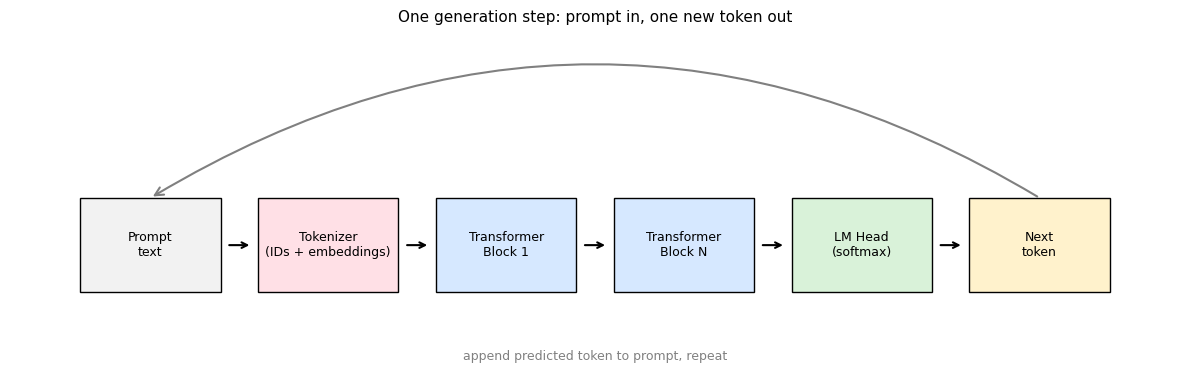

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

boxes = [
    ("Prompt\ntext",                 '#f2f2f2'),
    ("Tokenizer\n(IDs + embeddings)",'#ffe0e6'),
    ("Transformer\nBlock 1",         '#d6e8ff'),
    ("Transformer\nBlock N",         '#d6e8ff'),
    ("LM Head\n(softmax)",           '#d9f2d9'),
    ("Next\ntoken",                  '#fff2cc'),
]

n = len(boxes)
w, h = 0.12, 0.28
margin = 0.06
gap = (1 - 2 * margin - n * w) / (n - 1)   # even spacing, guaranteed to fit in [0,1]
y = 0.4

xs = [margin + i * (w + gap) for i in range(n)]

for (label, color), x in zip(boxes, xs):
    ax.add_patch(plt.Rectangle((x, y - h / 2), w, h, facecolor=color,
                                edgecolor='black', zorder=2))
    ax.text(x + w / 2, y, label, ha='center', va='center', fontsize=9, zorder=3)

# forward arrows between consecutive boxes, drawn in the gap so they never touch box edges
for i in range(n - 1):
    x0 = xs[i] + w
    x1 = xs[i + 1]
    ax.annotate('', xy=(x1 - 0.005, y), xytext=(x0 + 0.005, y),
                 arrowprops=dict(arrowstyle='->', lw=1.5, color='black'), zorder=1)

# loop-back arrow: Next token -> Prompt text, curving above the row (clear of the caption below)
loop_start = (xs[-1] + w / 2, y + h / 2)
loop_end = (xs[0] + w / 2, y + h / 2)
loop_arrow = FancyArrowPatch(
    loop_start, loop_end,
    connectionstyle="arc3,rad=0.3",
    arrowstyle='->', mutation_scale=15, lw=1.5, color='gray', zorder=1,
)
ax.add_patch(loop_arrow)
ax.text(0.5, 0.06, "append predicted token to prompt, repeat",
        fontsize=9, ha='center', color='gray')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.title("One generation step: prompt in, one new token out", fontsize=11, pad=15)
plt.tight_layout()
plt.show()

Notice the loop at the bottom: after the model predicts one token, that token gets appended to the prompt and the whole sequence runs through the model again to get the *next* token. Generating a 50-token response means 50 full forward passes, each one slightly longer than the last.

Within a single pass, all tokens in the current sequence are processed **in parallel**. Each token has its own computation path flowing through the stack of blocks simultaneously. The number of tokens a model can hold in this parallel computation at once is its **context length**. A 4K-context model runs 4,096 of these token streams side by side.


## 2. Decoding Strategies

The LM head's output is a probability distribution over the entire vocabulary (tens of thousands of numbers). How do we turn that into one chosen token?

- **Greedy decoding**: always pick the highest-probability token. Deterministic, but repetitive and the model gets stuck reusing "safe" words.
- **Sampling**: draw a token according to the probability distribution, so a less likely word occasionally gets picked. A **temperature** parameter controls how sharp or flat the distribution is before sampling: low temperature behaves close to greedy, high temperature flattens the distribution and increases randomness.

Let's implement both on a toy probability distribution over a 5-word vocabulary.

In [3]:
vocab = ["cat", "dog", "ran", "slept", "quickly"]
logits = np.array([2.5, 2.3, 1.0, 0.5, -0.2])  # raw scores from the LM head, before softmax

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

def greedy_decode(logits, vocab):
    return vocab[np.argmax(logits)]

def sample_decode(logits, vocab, temperature=1.0, rng=None):
    rng = rng or np.random.default_rng()
    probs = softmax(logits / temperature)
    return rng.choice(vocab, p=probs), probs

print("Greedy pick:", greedy_decode(logits, vocab))

rng = np.random.default_rng(7)
for temp in [0.3, 1.0, 2.0]:
    token, probs = sample_decode(logits, vocab, temperature=temp, rng=rng)
    print(f"\ntemperature={temp}")
    for w, p in zip(vocab, probs):
        print(f"  {w:10s} {p:.3f}")
    print("  sampled ->", token)


Greedy pick: cat

temperature=0.3
  cat        0.657
  dog        0.337
  ran        0.004
  slept      0.001
  quickly    0.000
  sampled -> cat

temperature=1.0
  cat        0.446
  dog        0.365
  ran        0.099
  slept      0.060
  quickly    0.030
  sampled -> ran

temperature=2.0
  cat        0.333
  dog        0.301
  ran        0.157
  slept      0.122
  quickly    0.086
  sampled -> ran


Watch how the distribution changes shape as temperature moves: at `temperature=0.3` almost all probability mass concentrates on "cat" (close to greedy), and by `temperature=2.0` the distribution is much flatter and any word is plausible. This single knob is why the same prompt to the same model can produce a careful, predictable answer or a much more varied one, depending on the setting.


## 3. Positional Encoding

Attention computes a weighted average over token vectors, and averaging doesn't care about order. If you shuffled the tokens of a sentence and fed them into attention with no other changes, you'd get the same set of output vectors in a different order. The model would have no idea "dog bites man" and "man bites dog" mean different things.

The fix used in the original Transformer is to add a **positional encoding** vector to each token embedding before it enters the first block, one fixed pattern per position, so position 0 always gets nudged one way and position 5 always gets nudged another way. The original paper's formula, for a model with dimension $d_{model}$:

$$PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right), \qquad PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Here $pos$ is the token's position in the sequence (0, 1, 2, ...) and $i$ indexes pairs of dimensions. Even dimensions get a sine, odd dimensions get the matching cosine, and each dimension pair oscillates at a different frequency, low $i$ = fast oscillation, high $i$ = slow. That mix of frequencies is what lets the network tell positions apart, including ones farther apart than it saw during training.

**Hand-calculation.** Let's compute the encoding for position $pos=1$ with $d_{model}=4$ (so $i \in \{0, 1\}$).

For $i=0$:
$$PE(1,0) = \sin\left(\frac{1}{10000^{0/4}}\right) = \sin(1) = 0.8415$$
$$PE(1,1) = \cos\left(\frac{1}{10000^{0/4}}\right) = \cos(1) = 0.5403$$

For $i=1$:
$$PE(1,2) = \sin\left(\frac{1}{10000^{2/4}}\right) = \sin\left(\frac{1}{100}\right) = \sin(0.01) \approx 0.0100$$
$$PE(1,3) = \cos\left(\frac{1}{10000^{2/4}}\right) = \cos(0.01) \approx 0.99995$$

So $PE(1, :) \approx [0.8415,\ 0.5403,\ 0.0100,\ 0.99995]$. Let's verify with code and generate the encoding for a longer sequence to see the pattern visually.

In [4]:
def positional_encoding(seq_len, d_model):
    pe = np.zeros((seq_len, d_model))
    position = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model // 2)
    div_term = 10000 ** (2 * i / d_model)
    pe[:, 0::2] = np.sin(position / div_term)
    pe[:, 1::2] = np.cos(position / div_term)
    return pe

pe_check = positional_encoding(seq_len=3, d_model=4)
print("PE(1, :) from code:", pe_check[1])
print("Matches hand calc:  [0.8415, 0.5403, 0.0100, 0.99995]")


PE(1, :) from code: [0.841 0.54  0.01  1.   ]
Matches hand calc:  [0.8415, 0.5403, 0.0100, 0.99995]



In practice this positional vector is just added elementwise to the token embedding before the first transformer block: `input = token_embedding + positional_encoding`. Note this is also exactly the kind of thing that changes across architectures, some newer models (like RoPE, which we'll mention in Section 8) inject position information differently, but the goal is identical: give attention something to distinguish "first" from "fifth."


### 3.1 Why This Actually Matters: "Man Bites Dog" vs. "Dog Bites Man"

The formula above shows *how* positional encoding is computed, but not yet *why* we need it. Let's connect it directly back to Week 2.

**Setup: turn each word into a vector.** We'll use simple toy embeddings, just like Week 2's lookup table, one fixed vector per word, 4-dimensional so it lines up with the positional encoding we just computed:

$$x_{man} = [1, 0, 0, 0] \qquad x_{bites} = [0, 1, 0, 0] \qquad x_{dog} = [0, 0, 1, 0]$$

This is exactly a Week 2-style embedding table: whichever sentence "man" appears in, looking it up always returns $[1,0,0,0]$. That's the static embedding property, and it's about to be the problem.

**Step 1: without positional encoding, order gets lost.** "Man bites dog", man is the 1st word. "Dog bites man", man is the 3rd word. Now compare man's vector in each sentence:

$$x_{man}\text{ in "man bites dog"} = [1,0,0,0]$$
$$x_{man}\text{ in "dog bites man"} = [1,0,0,0]$$

**Identical.** Not approximately, exactly. The embedding table has no idea "man" was the subject in one sentence and the object in the other, it just returns the same row every time. This is the direct extension of the static-embedding problem from Week 2: now it's not just word *meaning* that's frozen, it's word *role in the sentence* too.

**Step 2: add positional encoding to fix it.** Recall from just above, using $d_{model}=4$:

$$PE(0,:) = [0,\ 1,\ 0,\ 1] \qquad PE(1,:) = [0.8415,\ 0.5403,\ 0.0100,\ 0.9999] \qquad PE(2,:) = [0.9093,\ -0.4161,\ 0.0200,\ 0.9998]$$

Now, instead of feeding the raw word vector forward, we add the positional vector matching *where that word sits*:

"Man bites dog", man is at position 0:
$$x_{man} + PE(0,:) = [1,0,0,0] + [0,1,0,1] = [1,\ 1,\ 0,\ 1]$$

"Dog bites man", man is at position 2:
$$x_{man} + PE(2,:) = [1,0,0,0] + [0.9093,-0.4161,0.0200,0.9998] = [1.9093,\ -0.4161,\ 0.0200,\ 0.9998]$$

**Different vectors.** Same word, same starting embedding, but because each got tagged with its own position's encoding, "man-as-subject" and "man-as-object" are no longer indistinguishable. That's the whole fix, in one addition. Let's verify with code.

In [5]:
man   = np.array([1, 0, 0, 0], dtype=float)
bites = np.array([0, 1, 0, 0], dtype=float)
dog   = np.array([0, 0, 1, 0], dtype=float)

pe = positional_encoding(seq_len=3, d_model=4)

print("--- WITHOUT positional encoding ---")
print("man's vector in 'man bites dog' (position 0):", man)
print("man's vector in 'dog bites man' (position 2):", man)

print("\n--- WITH positional encoding ---")
man_sent1 = man + pe[0]   # man at position 0
man_sent2 = man + pe[2]   # man at position 2
print("man's vector in 'man bites dog' (position 0):", man_sent1.round(4))
print("man's vector in 'dog bites man' (position 2):", man_sent2.round(4))

--- WITHOUT positional encoding ---
man's vector in 'man bites dog' (position 0): [1. 0. 0. 0.]
man's vector in 'dog bites man' (position 2): [1. 0. 0. 0.]

--- WITH positional encoding ---
man's vector in 'man bites dog' (position 0): [1. 1. 0. 1.]
man's vector in 'dog bites man' (position 2): [ 1.909 -0.416  0.02   1.   ]


**One honest caveat, worth keeping in mind:** this fixes the *individual token's* vector, but it doesn't yet prove the *model's prediction* changes, that final step needs attention. This section's job is just to establish that the raw input to attention is no longer order-blind, which is the necessary first step. Positional encoding alone doesn't solve word order, it's what makes it *possible* for attention to notice order, not the mechanism that uses it. That's exactly where we're headed next.


## 4. Self-Attention, by Hand

In example: **"The dog chased the squirrel because it..."** For the model to predict the next word correctly, it needs to resolve what "it" refers to. Self-attention is the mechanism that lets the vector for "it" pull in information from "dog" and "squirrel" to help make that decision.

**The setup.** For the token currently being processed (the *query* position), attention compares it against every earlier token (including itself) and produces a new vector that's a weighted blend of those tokens' information, weighted by how relevant each one is.

Three learned weight matrices make this work, applied to every token's vector:

- $W_Q$ produces the **query**: "what am I looking for?"
- $W_K$ produces the **key**: "what do I contain, for others to match against?"
- $W_V$ produces the **value**: "what information do I actually contribute, once I'm picked?"

Given token vectors $x_1, \dots, x_n$, we compute $Q_j = x_j W_Q$, $K_j = x_j W_K$, $V_j = x_j W_V$ for every token $j$. Then for a query position $t$, attention proceeds in three steps:

$$\text{score}_{t,j} = \frac{Q_t \cdot K_j}{\sqrt{d_k}} \qquad \text{(relevance of token } j \text{ to the query)}$$
$$\alpha_{t,j} = \text{softmax}_j(\text{score}_{t,j}) \qquad \text{(normalize to sum to 1)}$$
$$\text{output}_t = \sum_j \alpha_{t,j}\, V_j \qquad \text{(weighted blend of values)}$$

The $\sqrt{d_k}$ scaling keeps the dot products from growing too large as dimension increases, which would otherwise push softmax into a regime with tiny gradients.

### 4.1 Why do we actually need three separate matrices?

Before working through the full calculation, it helps to see what goes wrong without $W_Q$, $W_K$, $W_V$, and then see exactly how adding them fixes it. We'll use the sentence's three content words that matter for this pronoun: "dog", "squirrel", "it".

Give each word a toy 4-dimensional embedding where the dimensions have a clear meaning for this demo: dim 1 = "dog-ish", dim 2 = "squirrel-ish", dim 3 = "is a pronoun", dim 4 = generic/shared.

$$x_{dog} = [1,0,0,1] \qquad x_{squirrel} = [0,1,0,1] \qquad x_{it} = [0,0,1,1]$$

Notice "it" has zero dog-signal and zero squirrel-signal on its own, it's a pronoun, it has no inherent meaning until it borrows meaning from context. That's exactly the real situation, and exactly what attention needs to fix.

#### Attempt 1: naive approach, raw dot product, no matrices at all

**Step 1, scores.** Each score is a dot product: multiply matching positions, add them up.

$$\text{score}(it,dog) = x_{it}\cdot x_{dog} = (0{\times}1)+(0{\times}0)+(1{\times}0)+(1{\times}1) = 0+0+0+1 = 1$$
$$\text{score}(it,squirrel) = x_{it}\cdot x_{squirrel} = (0{\times}0)+(0{\times}1)+(1{\times}0)+(1{\times}1) = 0+0+0+1 = 1$$
$$\text{score}(it,it) = x_{it}\cdot x_{it} = (0{\times}0)+(0{\times}0)+(1{\times}1)+(1{\times}1) = 0+0+1+1 = 2$$

**Dog and squirrel get the exact same score, 1 and 1.** Not close, identical.

**Step 2, softmax.** Softmax of $[1, 1, 2]$: exponentiate each, then divide by the sum.

$$e^1 = 2.7183 \qquad e^1 = 2.7183 \qquad e^2 = 7.3891$$
$$\text{sum} = 2.7183+2.7183+7.3891 = 12.8256$$
$$\alpha_{dog} = \frac{2.7183}{12.8256} = 0.2119 \qquad \alpha_{squirrel} = \frac{2.7183}{12.8256}=0.2119 \qquad \alpha_{it} = \frac{7.3891}{12.8256}=0.5761$$

**Step 3, weighted sum, one dimension at a time.** The output is $0.2119\,x_{dog} + 0.2119\,x_{squirrel} + 0.5761\,x_{it}$, computed separately for each of the 4 dimensions:

| dim | $0.2119 \times x_{dog}$ | $+\ 0.2119 \times x_{squirrel}$ | $+\ 0.5761 \times x_{it}$ | = |
|---|---|---|---|---|
| 1 | $0.2119\times 1 = 0.2119$ | $0.2119\times 0 = 0$ | $0.5761\times 0 = 0$ | **0.2119** |
| 2 | $0.2119\times 0 = 0$ | $0.2119\times 1 = 0.2119$ | $0.5761\times 0 = 0$ | **0.2119** |
| 3 | $0.2119\times 0 = 0$ | $0.2119\times 0 = 0$ | $0.5761\times 1 = 0.5761$ | **0.5761** |
| 4 | $0.2119\times 1 = 0.2119$ | $0.2119\times 1 = 0.2119$ | $0.5761\times 1 = 0.5761$ | **1.0** |

$$\text{output}_{it} = [0.212,\ 0.212,\ 0.576,\ 1.0]$$

The dimensions that matter are 1 and 2, dog-signal and squirrel-signal: **0.212 and 0.212, tied.** "It" ends up with a representation that's equally dog-flavored and squirrel-flavored. It doesn't mean dog. It doesn't mean squirrel either. Raw embeddings carry no mechanism for asking a directed question like "which noun am I referring back to?"

#### Attempt 2: with Q, K, V matrices

**The three matrices**, each $4\times2$ (4 rows to match the embedding dimension, 2 columns because we're projecting down to $d_k=2$):

$$W_Q = \begin{bmatrix}0&0\\0&0\\3&0\\0&0\end{bmatrix} \qquad W_K = \begin{bmatrix}1&0\\0&1\\0&0\\0&0\end{bmatrix} \qquad W_V = \begin{bmatrix}1&0\\0&1\\0&0\\0&0\end{bmatrix}$$

(For this toy example $W_V$ is set equal to $W_K$ purely so the output stays easy to read as "dog-signal, squirrel-signal." In general $W_V$ is a separate, independently learned matrix, it doesn't have to match $W_K$ at all, and in a real trained model it wouldn't.)

**How a row-vector-times-matrix multiplication works.** A matrix multiplication is only legal when the number of columns in the first thing matches the number of rows in the second thing. $x_{it}=[0,0,1,1]$ is a row vector, shape $1\times4$. $W_Q$ has shape $4\times2$. The inner numbers match (4 and 4), so the multiplication works, and the result is shape $1\times2$, a vector with 2 numbers.

To actually compute it: take $x_{it}$ and dot it against each **column** of $W_Q$ separately, one dot product per column.

**Step 1, compute $Q_{it}$.** Column 0 of $W_Q$ is $[0,0,3,0]$, column 1 is $[0,0,0,0]$.

$$Q_{it}[0] = x_{it}\cdot\text{col}_0(W_Q) = (0{\times}0)+(0{\times}0)+(1{\times}3)+(1{\times}0) = 3$$
$$Q_{it}[1] = x_{it}\cdot\text{col}_1(W_Q) = (0{\times}0)+(0{\times}0)+(1{\times}0)+(1{\times}0) = 0$$
$$Q_{it} = [3,\ 0]$$

**Step 2, compute the three keys.** Columns of $W_K$: column 0 is $[1,0,0,0]$, column 1 is $[0,1,0,0]$.

$$K_{dog}[0]=(1{\times}1)+(0{\times}0)+(0{\times}0)+(1{\times}0)=1 \qquad K_{dog}[1]=(1{\times}0)+(0{\times}1)+(0{\times}0)+(1{\times}0)=0 \qquad K_{dog}=[1,\ 0]$$
$$K_{squirrel}[0]=(0{\times}1)+(1{\times}0)+(0{\times}0)+(1{\times}0)=0 \qquad K_{squirrel}[1]=(0{\times}0)+(1{\times}1)+(0{\times}0)+(1{\times}0)=1 \qquad K_{squirrel}=[0,\ 1]$$
$$K_{it}[0]=(0{\times}1)+(0{\times}0)+(1{\times}0)+(1{\times}0)=0 \qquad K_{it}[1]=(0{\times}0)+(0{\times}1)+(1{\times}0)+(1{\times}0)=0 \qquad K_{it}=[0,\ 0]$$

**Step 3, compute the three values.** $W_V$ has the same columns as $W_K$ here, so the arithmetic is identical in form:

$$V_{dog} = [1,\ 0] \qquad V_{squirrel} = [0,\ 1] \qquad V_{it} = [0,\ 0]$$

**Step 4, raw scores.** Dot the query against each key:

$$\text{score}(it,dog) = Q_{it}\cdot K_{dog} = (3{\times}1)+(0{\times}0) = 3$$
$$\text{score}(it,squirrel) = Q_{it}\cdot K_{squirrel} = (3{\times}0)+(0{\times}1) = 0$$
$$\text{score}(it,it) = Q_{it}\cdot K_{it} = (3{\times}0)+(0{\times}0) = 0$$

Already, before any softmax: **3 vs. 0 vs. 0.** Compare this to Attempt 1's tied $1$ vs. $1$, this is the moment the tie breaks.

**Step 5, scale.** $d_k=2$, so divide every score by $\sqrt{2}=1.41421$:

$$\frac{3}{1.41421}=2.12132 \qquad \frac{0}{1.41421}=0 \qquad \frac{0}{1.41421}=0$$

**Step 6, softmax.**

$$e^{2.12132} = 8.34214 \qquad e^0=1 \qquad e^0=1 \qquad \text{sum} = 8.34214+1+1=10.34214$$
$$\alpha_{dog}=\frac{8.34214}{10.34214}=0.8066 \qquad \alpha_{squirrel}=\frac{1}{10.34214}=0.0967 \qquad \alpha_{it}=\frac{1}{10.34214}=0.0967$$

**Step 7, weighted sum, one dimension at a time.** Output $= 0.8066\,V_{dog} + 0.0967\,V_{squirrel} + 0.0967\,V_{it}$:

| dim | $0.8066 \times V_{dog}$ | $+\ 0.0967\times V_{squirrel}$ | $+\ 0.0967\times V_{it}$ | = |
|---|---|---|---|---|
| 1 | $0.8066\times1=0.8066$ | $0.0967\times0=0$ | $0.0967\times0=0$ | **0.8066** |
| 2 | $0.8066\times0=0$ | $0.0967\times1=0.0967$ | $0.0967\times0=0$ | **0.0967** |

$$\text{output}_{it} = [0.807,\ 0.097]$$

#### Side by side

| | attention weight on dog | attention weight on squirrel | output dog-signal | output squirrel-signal |
|---|---|---|---|---|
| **Naive (no matrices)** | 0.212 | 0.212 | 0.212 | 0.212 |
| **With $Q,K,V$** | **0.807** | 0.097 | **0.807** | 0.097 |

Without $Q$, $K$, $V$, "it" comes out of attention exactly as ambiguous as it went in, a coin flip encoded as a vector. With $Q$, $K$, $V$ in play, "it" comes out 80.7% dog-flavored, a decisive resolution the model can use to correctly predict whatever comes next.

One honest note: these specific numbers ($W_Q$, $W_K$, $W_V$ above) were hand-designed to produce this clean contrast, not randomly generated and not trained. What's real is the mechanism, separate projections can turn a tie into a decisive preference. What's illustrative is the specific numbers, a real trained model reaches a similar decisive outcome, but through weights shaped by gradient descent over millions of sentences, not through matrices someone hand-picked to make the arithmetic come out cleanly. Let's verify all of this with code.

In [6]:
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

# dimensions: 1 = dog-ish, 2 = squirrel-ish, 3 = is-a-pronoun, 4 = generic/shared
x_dog      = np.array([1, 0, 0, 1], dtype=float)
x_squirrel = np.array([0, 1, 0, 1], dtype=float)
x_it       = np.array([0, 0, 1, 1], dtype=float)

print("="*60)
print("ATTEMPT 1: naive approach (raw dot product, no matrices)")
print("="*60)
score_dog      = x_it @ x_dog
score_squirrel = x_it @ x_squirrel
score_it       = x_it @ x_it
print("score(it, dog)      =", score_dog)
print("score(it, squirrel) =", score_squirrel)
print("score(it, it)       =", score_it)

weights_naive = softmax(np.array([score_dog, score_squirrel, score_it]))
print("\nsoftmax weights [dog, squirrel, it]:", weights_naive.round(4))

output_naive = weights_naive[0]*x_dog + weights_naive[1]*x_squirrel + weights_naive[2]*x_it
print("output vector for 'it':", output_naive.round(4))
print("  dog-signal =", round(output_naive[0], 4), "  squirrel-signal =", round(output_naive[1], 4))

print()
print("="*60)
print("ATTEMPT 2: with Q, K, V matrices")
print("="*60)
W_Q = np.array([
    [0,0],
    [0,0],
    [3,0],   # pronoun dimension projects toward the dog-key direction
    [0,0],
], dtype=float)

W_K = np.array([
    [1,0],   # dog dimension -> key dim 1
    [0,1],   # squirrel dimension -> key dim 2
    [0,0],
    [0,0],
], dtype=float)

W_V = np.array([
    [1,0],
    [0,1],
    [0,0],
    [0,0],
], dtype=float)

Q_it = x_it @ W_Q
K_dog, K_squirrel, K_it = x_dog @ W_K, x_squirrel @ W_K, x_it @ W_K
V_dog, V_squirrel, V_it = x_dog @ W_V, x_squirrel @ W_V, x_it @ W_V

print("Q_it =", Q_it)
print("K_dog =", K_dog, " K_squirrel =", K_squirrel, " K_it =", K_it)
print("V_dog =", V_dog, " V_squirrel =", V_squirrel, " V_it =", V_it)

d_k = 2
raw_scores = np.array([Q_it @ K_dog, Q_it @ K_squirrel, Q_it @ K_it])
scaled_scores = raw_scores / np.sqrt(d_k)
print("\nraw scores [dog, squirrel, it]:", raw_scores)
print("scaled scores (divide by sqrt(2)):", scaled_scores.round(4))

weights_qkv = softmax(scaled_scores)
print("softmax weights [dog, squirrel, it]:", weights_qkv.round(4))

output_qkv = weights_qkv[0]*V_dog + weights_qkv[1]*V_squirrel + weights_qkv[2]*V_it
print("output vector for 'it':", output_qkv.round(4))
print("  dog-signal =", round(output_qkv[0], 4), "  squirrel-signal =", round(output_qkv[1], 4))

print()
print("="*60)
print("SIDE-BY-SIDE COMPARISON")
print("="*60)
print(f"{'':22s} {'dog-signal':>12s} {'squirrel-signal':>18s}")
print(f"{'Naive (no matrices)':22s} {output_naive[0]:12.3f} {output_naive[1]:18.3f}")
print(f"{'With Q, K, V':22s} {output_qkv[0]:12.3f} {output_qkv[1]:18.3f}")

ATTEMPT 1: naive approach (raw dot product, no matrices)
score(it, dog)      = 1.0
score(it, squirrel) = 1.0
score(it, it)       = 2.0

softmax weights [dog, squirrel, it]: [0.212 0.212 0.576]
output vector for 'it': [0.212 0.212 0.576 1.   ]
  dog-signal = 0.2119   squirrel-signal = 0.2119

ATTEMPT 2: with Q, K, V matrices
Q_it = [3. 0.]
K_dog = [1. 0.]  K_squirrel = [0. 1.]  K_it = [0. 0.]
V_dog = [1. 0.]  V_squirrel = [0. 1.]  V_it = [0. 0.]

raw scores [dog, squirrel, it]: [3. 0. 0.]
scaled scores (divide by sqrt(2)): [2.121 0.    0.   ]
softmax weights [dog, squirrel, it]: [0.807 0.097 0.097]
output vector for 'it': [0.807 0.097]
  dog-signal = 0.8066   squirrel-signal = 0.0967

SIDE-BY-SIDE COMPARISON
                         dog-signal    squirrel-signal
Naive (no matrices)           0.212              0.212
With Q, K, V                  0.807              0.097


## Self Attention with Pytorch

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, d_model, d_k):
        super().__init__()
        self.d_k = d_k
        self.W_Q = nn.Linear(d_model, d_k, bias=False)
        self.W_K = nn.Linear(d_model, d_k, bias=False)
        self.W_V = nn.Linear(d_model, d_k, bias=False)

    def forward(self, x):
        batch, seq_len, d_model = x.shape

        Q = self.W_Q(x)  # (batch, seq_len, d_k)
        K = self.W_K(x)
        V = self.W_V(x)

        scores = Q @ K.transpose(-2, -1) / (self.d_k ** 0.5) 
        weights = torch.softmax(scores, dim=-1)
        output = weights @ V  # (batch, seq_len, d_k)

        return output, weights

# same toy tokens and hand-picked matrices as the NumPy version above
x_dog      = torch.tensor([1., 0., 0., 1.])
x_squirrel = torch.tensor([0., 1., 0., 1.])
x_it       = torch.tensor([0., 0., 1., 1.])
x = torch.stack([x_dog, x_squirrel, x_it]).unsqueeze(0)  # (batch=1, seq_len=3, d_model=4)

attn = SelfAttention(d_model=4, d_k=2)
with torch.no_grad():
    attn.W_Q.weight.copy_(torch.tensor([[0.,0.],[0.,0.],[3.,0.],[0.,0.]]).T)
    attn.W_K.weight.copy_(torch.tensor([[1.,0.],[0.,1.],[0.,0.],[0.,0.]]).T)
    attn.W_V.weight.copy_(torch.tensor([[1.,0.],[0.,1.],[0.,0.],[0.,0.]]).T)

output, weights = attn(x)
print("Attention weights for 'it' -> [dog, squirrel, it]:", weights[0, 2].tolist())
print("Output vector for 'it':", output[0, 2].tolist())

## 5. Where This Leaves Us

This week we opened up the black box between tokenization and text generation, and answered the question a bag-of-words model could never even ask: how does a model figure out what a word actually means in this specific sentence?

We built the full forward pass pipeline, saw how decoding strategies turn a probability distribution into an actual choice of word, and solved the ordering problem with positional encoding, proving directly, with real vectors, that without it, "man bites dog" and "dog bites man" hand attention the exact same information to work with. Then we tackled the core mechanism itself: self-attention. We didn't just learn the formula, we proved why it needs three separate matrices rather than one, by showing a plain, matrix-free comparison forces "it" to treat "dog" and "squirrel" as equally relevant, a tie, and then showing that splitting the comparison into query, key, and value roles breaks that tie decisively.

That's the real milestone this week: attention is no longer a name for a mysterious box, it's an operation you've computed by hand, matrix by matrix, and verified against code line by line.

Week 4 is where the rest of the architecture comes together, in one continuous arc: multi-head attention (why one head genuinely isn't enough, worked by hand before it's written in code), causal masking (making sure a token can't peek at what comes after it), and assembling a full transformer block (wiring attention together with residual connections, layer normalization, and a feedforward network). All three pieces feed directly into the week's actual milestone: assembling a small, real transformer architecture and training it from scratch on real text, watching it go from producing gibberish to producing something recognizably language-like.
